# Вспомогательное

In [1]:
import numpy as np

import math
#from math import factorial

import scipy.integrate
import scipy.special
from scipy.special import kn #Macdonald function
from scipy.special import genlaguerre
from scipy.special import eval_genlaguerre
from scipy.special import expi
from scipy.signal import savgol_filter
from scipy.ndimage import gaussian_filter1d

import torch
import torch.special
from torch.autograd import Function
from torch.special import gammaln
%pip install torchquad
import torchquad
from torchquad import GaussLegendre

from sympy.physics.quantum.spin import WignerD

import matplotlib.pyplot as plt

%pip install PyWavelets
import pywt

from tqdm import tqdm


[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [6]:
# Установим dtype и device для PyTorch (можно изменить при необходимости)
dtype = torch.float32
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# "Стандартные" значения параметров
m = torch.tensor(1.0, dtype=dtype, device=device) # Масса частицы = масса электрона: 1
sigma = torch.tensor(2590.0, dtype=dtype, device=device) # Продольная ширина волнового пакета в компотоновских длинах волн: 2590 -> 1 nm
pzi = torch.tensor(0.196, dtype=dtype, device=device) # Продольный импульс начального электрона: 0.196 -> 100keV
si = 1 #
li = 1 # Орбитальное квантовое число начального электрона
pzf = torch.tensor(0.19599, dtype=dtype, device=device) # Продольный импульс конечного электрона: 0.19599 -> 99 994.9 eV
sf = 1
lf = 1 # Орбитальное квантовое число конечного электрона

kz = torch.tensor(1.96e-6, dtype=dtype, device=device) # Величина продольного импульса фотона: 1.96e-6 -> 1 eV
kp = torch.tensor(1.96e-7, dtype=dtype, device=device) # Величина поперечного импульса фотона: 1.96e-7 -> 0.1 eV
phi_k = torch.tensor(0.0, dtype=dtype, device=device) # Азимутальный угол импульса фотона: 0

lambda_ = torch.tensor(1.0, dtype=dtype, device=device) # Спиральность фотона: 1
F0 = torch.tensor(7.57e-8, dtype=dtype, device=device) # Сила со стороны электрического поля на заряд: 7.57e-8 -> 100 MeV/m
# t_C = 1.287e-21 s
# lambda_C = 3.86e-13 m
t_in = torch.tensor(2.56e7, dtype=dtype, device=device) # Время начала наблюдения: 2.56e7 t_c = 3.3e-8 s (соответствует расстоянию в 10 мкм при v = c)
t_out = torch.tensor(2.56e10, dtype=dtype, device=device) # Время пролёта ускорителя: 2.56e10 t_c = 3.3e-11 s (соответствует расстоянию в 1 см при v = c)
# H_c = 4.41e9 T
HtoHc = torch.tensor(2.27e-10, dtype=dtype, device=device) # Величина магнитного поля: 2.27e-10 -> 1T
rho_H = 2.0 / torch.sqrt(HtoHc) # Магнитная длина: для H = 1 T магнитная длина 132 744 комптоновских длин волн или 5.12e-8 m = 0.512 nm
# 1 / rho_H соответствует импульсу 7.53e-6 или 3.85 eV
q = torch.tensor(7.297e-3).sqrt().to(dtype=dtype, device=device) # Величина заряда частицы: 7.297e-3 -> q_e
sign = torch.tensor(-1.0, dtype=dtype, device=device) # Знак заряда частицы

kp_max = torch.tensor(1e-4, dtype=dtype, device=device) # Верхний предел интегрирования по величине поперечного импульса фотона: 1e-4 -> 51.1 eV
# kp_max должен быть заметно больше 1 / rho_H
pzf_min = -F0 * t_out # Нижний предел интегрирования по продольному импульсу конечного электрона
# Для F0 = 7.57e-8 = 100 MeV/m и t_out = 2.56e10 = 3.3e-11 s получаем pzf_min = 1.938e3 = 0.99 GeV
print(10/F0)



tensor(1.3210e+08)


In [7]:

def factorial(n):
    if isinstance(n, torch.Tensor):
        return torch.exp(torch.special.gammaln(n + 1))
    else:
        n_tensor = torch.tensor(n, dtype=dtype, device=device)
        return torch.exp(torch.special.gammaln(n_tensor + 1))

# Полиномы Лагерра с положительными верхними индексами
def L_mod_1(n, alpha, x):
    # x — torch.tensor
    if n == 0:
        return torch.ones_like(x)
    elif n == 1:
        return 1 + alpha - x
    else:
        L0 = torch.ones_like(x)
        L1 = 1 + alpha - x
        for k in range(2, n + 1):
            Lk = ((2 * k - 1 + alpha - x) * L1 - (k - 1 + alpha) * L0) / k
            L0, L1 = L1, Lk
        return L1

# Полиномы Лагерра с отрицательными верхними индексами
def L_mod(n, alpha, x):
    if alpha > -1:
        return L_mod_1(n,alpha,x)
    else:
        return L_mod_1(n+alpha,-alpha,x)*(-x)**(-alpha)*factorial(n+alpha)/factorial(n)

# Квадрат поперечного импульса
def pp2(s, l, HtoHc, sign):
    l = torch.tensor(l, dtype=dtype, device=device)
    l_abs = torch.abs(l)
    return 2 * HtoHc * (s + l_abs / 2 - sign * l / 2 + 0.5)

# Классическая функция энергии
def En(s, l, pz, t, HtoHc, sign, F0, m):
    return torch.sqrt(m**2 + pp2(s, l, HtoHc, sign) + (pz + F0 * t)**2)

# Классическая продольная траектория
def z(s, l, pz, t, HtoHc, sign, F0, m):
    return (En(s, l, pz, t, HtoHc, sign, F0, m) - En(s, l, pz, 0.0, HtoHc, sign, F0, m)) / F0

# Интеграл от энергии от 0 до t, входящий в действие (здесь интегрируем именно от 0, а не от t_in)
def IntEn(s, l, pz, t, HtoHc, sign, F0, m):
    En_t  = En(s, l, pz, t, HtoHc, sign, F0, m)
    En_0  = En(s, l, pz, 0.0, HtoHc, sign, F0, m)
    En00  = En(s, l, 0.0, 0.0, HtoHc, sign, F0, m)

    term1 = (pz + F0 * t) * En_t - pz * En_0

    num   = pz + F0 * t + En_t
    denom = pz + En_0
    # avoid div by 0 or negative log
    eps = 1e-30
    frac = torch.clamp(torch.abs(num / denom), min=eps)

    term2 = En00**2 * torch.log(frac)

    return (term1 + term2) / (2 * F0)

# Интегральная экспонента
class Exp1Function(Function):
    @staticmethod
    def forward(ctx, input):
        input_np = input.detach().cpu().numpy()
        output_np = scipy.special.exp1(input_np)  # для комплексных значений
        output = torch.from_numpy(np.array(output_np)).to(input.device).type_as(input)
        ctx.save_for_backward(input)
        return output

    @staticmethod
    def backward(ctx, grad_output):
        input, = ctx.saved_tensors
        grad_input = -torch.exp(-input) / input
        return grad_output * grad_input

def exp1(x: torch.Tensor) -> torch.Tensor:
    return Exp1Function.apply(x)

# Интеграл по времени от t_in до бесконечности в приближении F0 * t >> pzi, pzf
def K(kp, pzi, pzf, t_in):
    kz = pzi - pzf
    dpz = pzi + pzf
    phase = -1j / (2 * F0) * (torch.sqrt(kp ** 2 + kz ** 2) - kz) * dpz
    arg = -1j * (torch.sqrt(kp ** 2 + kz ** 2) - kz + 1j * 1e-40) * (t_in + dpz / (2 * F0))
    return torch.exp(phase) * exp1(arg)

# интеграл по времени от t_in до t_out
def Kprime(kp, pzi, pzf, t_in, t_out):
    return K(kp, pzi, pzf, t_in) - K(kp, pzi, pzf, t_out)

# Интеграл по поперечной координате
def Ffun(si, li, sf, lf, y):
    sf_lf_fact = factorial(sf + lf)
    si_fact = factorial(si)

    exponent = 3*(si - sf) + 2*li - lf + 2
    y_power = y**(2*(si - sf) + li - lf)

    y_sq = y**2
    L1 = L_mod(sf + lf, (si - sf + li - lf), y_sq / torch.tensor(8, dtype=dtype, device=device))
    L2 = L_mod(sf, (si - sf), y_sq / torch.tensor(8, dtype=dtype, device=device))

    exp_term = torch.exp(-y_sq / torch.tensor(8, dtype=dtype, device=device))

    return (sf_lf_fact / si_fact) * (1 / 2**exponent) * y_power * L1 * L2 * exp_term

def Ip1(si, li, sf, lf, y):
    term1 = 2 * Ffun(si, li, sf, lf + 1, y)
    term2 = (si + li) * Ffun(si, li - 1, sf, lf, y)
    return (-1j) * torch.sqrt(torch.tensor(2.0, device=device)) * (term1 + term2)

def Im1(si, li, sf, lf, y):
    term1 = 2 * Ffun(si, li + 1, sf, lf, y)
    term2 = (sf + lf) * Ffun(si, li, sf, lf - 1, y)
    return (-1j) * torch.sqrt(torch.tensor(2.0, device=device)) * (term1 + term2)

# Регуляризация
eps = torch.tensor(1e-30)

# Члены суммы по проекциям спина фотона на ось z в S_fi
def TT_wide(si, li, pzi, sf, lf, pzf, kp, y, tin, tout):
    kz = pzi - pzf
    omega = torch.sqrt(kp**2 + kz**2)

    tint1 = Kprime(kp, pzi, pzf, tin, tout) / F0
    denominator = 1j * (omega - kz + 1j * eps)
    tint0 = (2 * torch.exp(1j * (omega - kz) * tin)) / denominator - \
            (2 * torch.exp(1j * (omega - kz) * tout)) / denominator

    term1 = Im1(si, li, sf, lf, y) * tint1
    term2 = rho_H * Ffun(si, li, sf, lf, y) * tint0
    term3 = Ip1(si, li, sf, lf, y) * tint1

    return torch.stack([term1, term2, term3])

def wigner_d_matrix_j1_torch(sigma_pol: int, lambda_val: int, beta: torch.Tensor) -> torch.Tensor:

    # Убедимся, что beta является тензором и на правильном устройстве
    if not isinstance(beta, torch.Tensor):
        raise TypeError("beta must be a torch.Tensor")

    # Определение dtype и device из beta
    dtype = beta.dtype
    device = beta.device

    cos_beta = torch.cos(beta)
    sin_beta = torch.sin(beta)
    sqrt_2 = torch.sqrt(torch.tensor(2.0, dtype=dtype, device=device))

    # d^1_{m'm}(beta)
    # Используем сложную структуру if/elif/else для охвата всех 9 элементов матрицы.
    # Это позволяет избежать создания большой таблицы поиска и делает логику явной.

    if sigma_pol == 1:
        if lambda_val == 1:
            return (1 + cos_beta) / 2
        elif lambda_val == -1:
            return (1 - cos_beta) / 2
    elif sigma_pol == 0:
        if lambda_val == 1:
            return sin_beta / sqrt_2
        elif lambda_val == -1:
            return -sin_beta / sqrt_2
    elif sigma_pol == -1:
        if lambda_val == 1:
            return (1 - cos_beta) / 2
        elif lambda_val == -1:
            return (1 + cos_beta) / 2

    # Если индексы sigma_pol или lambda_val выходят за пределы [-1, 0, 1]
    raise ValueError(f"Недопустимые индексы для j=1 d-матрицы: sigma_pol={sigma_pol}, lambda_val={lambda_val}. Они должны быть -1, 0 или 1.")


# Матричный элемент в приближении широкого пакета
def Sfi_wide(si, li, pzi, sf, lf, pzf, kp, phi_k, lambda_, t_in, t_out):
    # Ensure all inputs are tensors and on the correct device
    # Convert scalar inputs to tensors if they aren't already

    si_t = torch.tensor(si, dtype=dtype, device=device) if not isinstance(si, torch.Tensor) else si.clone().detach()
    li_t = torch.tensor(li, dtype=dtype, device=device) if not isinstance(li, torch.Tensor) else li.clone().detach()
    sf_t = torch.tensor(sf, dtype=dtype, device=device) if not isinstance(sf, torch.Tensor) else sf.clone().detach()
    lf_t = torch.tensor(lf, dtype=dtype, device=device) if not isinstance(lf, torch.Tensor) else lf.clone().detach()
    lambda_t = torch.tensor(lambda_, dtype=dtype, device=device) if not isinstance(lambda_, torch.Tensor) else lambda_.clone().detach()
    # Pre-calculate common terms for efficiency
    pzi_minus_pzf = pzi - pzf
    kp_sq_plus_pzm_sq = kp**2 + pzi_minus_pzf**2

    sqrt1 = torch.sqrt((2**(torch.abs(li_t) + 1)) / (torch.pi * rho_H**2) * factorial(si_t) / factorial(si_t + li_t))
    sqrt2 = torch.sqrt((2**(torch.abs(lf_t) + 1)) / (torch.pi * rho_H**2) * factorial(sf_t) / factorial(sf_t + lf_t))

    photon_norm = 1 / torch.sqrt(2 * torch.sqrt(kp_sq_plus_pzm_sq))
    # Общий префактор
    prefactor = -2 * torch.pi * 1j * photon_norm * sqrt1 * sqrt2 * (q * rho_H) / (2 * m)
    exp_term = torch.exp(1j * (li_t - lf_t) * phi_k)


    # Второй член в разложении разности координат
    z_exp_factor = torch.exp(-(pzi - En(si, li, pzi, 0, HtoHc, sign, F0, m) - pzf + En(sf, lf, pzf, 0, HtoHc, sign, F0, m))**2 / F0**2 / (4 * sigma**2))


    # Вычисление суммы

    total_sum = torch.zeros_like(kp, dtype=torch.complex128, device=device)
    # Calculate the angle for WignerD
    angle_for_wigner_d = torch.atan2(kp, pzi_minus_pzf)
    # Convert lambda_ to int for wigner_d_matrix_j1_torch
    lambda_int = int(lambda_t.item()) # Use .item() to get Python scalar from 0-dim tensor
    for sigma_pol in range(-1, 2):  # sigma_pol = -1, 0, 1
        i_power = (1j)**(sigma_pol - li_t + lf_t)
        # Get the Wigner D value using the new PyTorch function
        wigner_d_val = wigner_d_matrix_j1_torch(sigma_pol, lambda_int, angle_for_wigner_d)
        # Get the corresponding element from TT
        # Ensure si, li, sf, lf are passed as Python ints to TT_wide's internal functions
        tt_elements = TT_wide(int(si_t.item()), int(li_t.item()), pzi, int(sf_t.item()), int(lf_t.item()), pzf, kp, kp * rho_H, t_in, t_out)
        tt_element = tt_elements[sigma_pol + 1]
        # Add to the sum
        total_sum += i_power * wigner_d_val * tt_element
    result = prefactor * exp_term * total_sum * z_exp_factor
    return result


# TT_wide

In [8]:
def TT_wide_Texact(si, li, pzi, sf, lf, pzf, kp, y, tin, tout):
    # Преобразуем скалярные si, li, sf, lf в int для передачи в функции,
    # которые могут ожидать обычные числа (хотя лучше, если они тоже работают с тензорами).
    si, li, sf, lf = int(si), int(li), int(sf), int(lf)

    # Вычисляем константы один раз
    kz = pzi - pzf
    omega = torch.sqrt(kp**2 + kz**2)

    gl = torchquad.GaussLegendre()

    # --- Создаем ЕДИНУЮ векторизованную подынтегральную функцию ---
    def unified_integrand(t_batch, mode):
        # t_batch имеет форму [N, 1], преобразуем в [N] для удобства
        t = t_batch.squeeze(-1)

        # --- Векторизованные вычисления! Нет циклов! Все операции - torch.* ---
        En_i = En(si, li, pzi, t, HtoHc, sign, F0, m)
        En_f = En(sf, lf, pzf, t, HtoHc, sign, F0, m)
        z_i = z(si, li, pzi, t, HtoHc, sign, F0, m)
        z_f = z(sf, lf, pzf, t, HtoHc, sign, F0, m)

        # Общие части для обоих интегралов
        # Добавляем eps для численной стабильности, чтобы избежать деления на ноль
        eps = 1e-30
        prefactor_common = 1.0 / torch.sqrt(torch.clamp(En_i * En_f, min=eps))

        z_diff_sq = (z_i - z_f)**2
        exp1 = torch.exp(-z_diff_sq / (4 * sigma**2))

        int_en_diff = IntEn(si, li, pzi, t, HtoHc, sign, F0, m) - IntEn(sf, lf, pzf, t, HtoHc, sign, F0, m)
        z_sum = z_i + z_f
        phase = omega * t - int_en_diff - z_sum * (pzf - pzi + kz) / 2.0
        exp2 = torch.exp(1j * phase)

        # Различающиеся части
        if mode == 'integrand1':
            # Для tint1_Texact у нас просто 1.0 в качестве множителя
            # (но мы оставим его для общности)
            numerator = torch.ones_like(t, dtype=torch.complex128)
        elif mode == 'integrand0':
            # Для tint0_Texact
            numerator = -pzi - pzf - 2 * F0 * t + 1j * (z_i - z_f) / sigma**2
        else:
            raise ValueError("Unknown mode")

        return numerator * prefactor_common * exp1 * exp2

    # --- Вычисляем интегралы ---
    # Используем lambda-функции, чтобы передать параметр 'mode' в наш унифицированный интегранд

    # Интеграл для tint1
    tint1_Texact = gl.integrate(
        lambda t: unified_integrand(t, mode='integrand1'),
        dim=1, N=101, integration_domain=[[tin, tout]]
    )

    # Интеграл для tint0
    tint0_Texact = gl.integrate(
        lambda t: unified_integrand(t, mode='integrand0'),
        dim=1, N=101, integration_domain=[[tin, tout]]
    )

    # Собираем результат так же, как и раньше
    term1 = Im1(si, li, sf, lf, y) * tint1_Texact
    term2 = rho_H * Ffun(si, li, sf, lf, y) * tint0_Texact
    term3 = Ip1(si, li, sf, lf, y) * tint1_Texact # В вашем коде тут tint1, предполагаю, что это правильно

    return torch.stack([term1, term2, term3])

def TT_wide_Texact_float32(*args, **kwargs):
    global dtype
    dtype = torch.float32
    return TT_wide_Texact(*args, **kwargs)

def TT_wide_Texact_float64(*args, **kwargs):
    global dtype
    dtype = torch.float64
    return TT_wide_Texact(*args, **kwargs)

/home/ulyana/Itmo/.venv/lib/python3.12/site-packages/autoray/autoray.py:81: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return func(*args, **kwargs)
/home/ulyana/Itmo/.venv/lib/python3.12/site-packages/torchquad/integration/utils.py:248: UserWarning: DEPRECATION WARNING: In future versions of torchquad, an array-like object will be returned.
  warnings.warn(


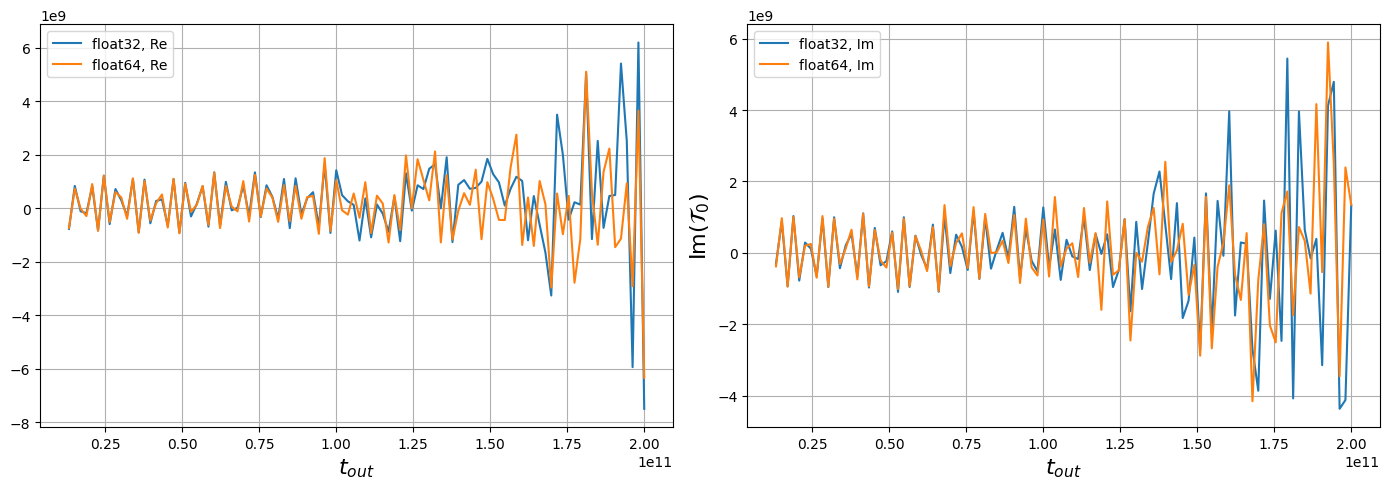

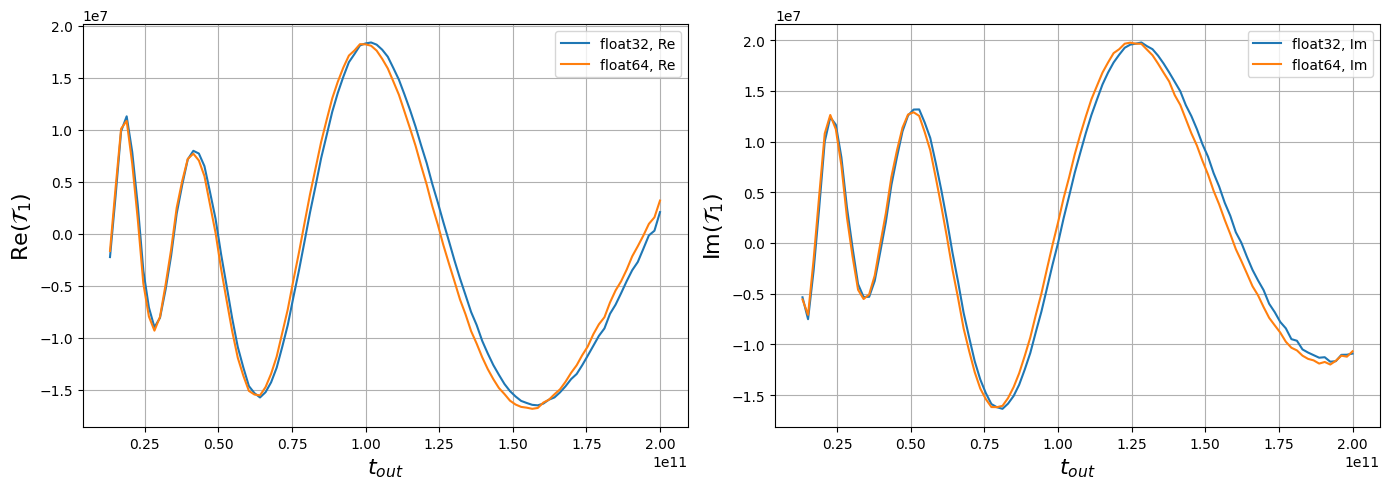

In [9]:


# tspec = np.linspace (1.32e8, 2.6e10, 100) #- tint0 like approx

# tspec = np.linspace (1.32e11, 2e11, 100) #- difficult to see the beginning of difference for tint0, 4.3e9
tspec = np.linspace(1.32e10, 2e11, 100)  
# tspec = np.linspace(1.1e11, 2e11, 100) 


tint0_Texact_float32 = [TT_wide_Texact_float32(si, li, pzi, sf, lf, pzf, kp, kp*rho_H, t_in, T)[1] / (rho_H * Ffun(si, li, sf, lf, kp*rho_H)) for T in tspec]
tint0_Texact_float64 = [TT_wide_Texact_float64(si, li, pzi, sf, lf, pzf, kp, kp*rho_H, t_in, T)[1] / (rho_H * Ffun(si, li, sf, lf, kp*rho_H)) for T in tspec]
tint0 = [TT_wide(si, li, pzi, sf, lf, pzf, kp, kp*rho_H, t_in, T)[1] / (rho_H * Ffun(si, li , sf, lf, kp*rho_H)) for T in tspec]

tint1_Texact_float32 = [TT_wide_Texact_float32(si, li, pzi, sf, lf, pzf, kp, kp*rho_H, t_in, T)[0] / Im1(si, li, sf, lf, kp*rho_H) for T in tspec]
tint1_Texact_float64 = [TT_wide_Texact_float64(si, li, pzi, sf, lf, pzf, kp, kp*rho_H, t_in, T)[0] / Im1(si, li, sf, lf, kp*rho_H) for T in tspec]
tint1 = [TT_wide(si, li, pzi, sf, lf, pzf, kp, kp*rho_H, t_in, T)[0] / Im1(si, li, sf, lf, kp*rho_H) for T in tspec]

# Create a figure with 2 subplots (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot real parts on the first subplot
ax1.plot(tspec, np.array(tint0_Texact_float32).real, label='float32, Re')
ax1.plot(tspec, np.array(tint0_Texact_float64).real, label='float64, Re')
#ax1.plot(tspec, np.array(tint0).real, label='Approx, Re')
ax1.legend()
ax1.grid()
ax1.set_xlabel("$t_{out}$", fontsize=16)

# Plot imaginary parts on the second subplot
ax2.plot(tspec, np.array(tint0_Texact_float32).imag, label='float32, Im')
ax2.plot(tspec, np.array(tint0_Texact_float64).imag, label='float64, Im')
ax2.legend()
ax2.grid()
ax2.set_xlabel("$t_{out}$", fontsize=16)
ax2.set_ylabel("Im($\mathcal{T}_0$)", fontsize=16)

# Adjust layout and show
plt.tight_layout()
plt.show()

# Create a figure with 2 subplots (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot real parts on the first subplot
ax1.plot(tspec, np.array(tint1_Texact_float32).real, label='float32, Re')
ax1.plot(tspec, np.array(tint1_Texact_float64).real, label='float64, Re')
ax1.legend()
ax1.grid()
ax1.set_xlabel("$t_{out}$", fontsize=16)
ax1.set_ylabel("Re($\mathcal{T}_1$)", fontsize=16)

# Plot imaginary parts on the second subplot
ax2.plot(tspec, np.array(tint1_Texact_float32).imag, label='float32, Im')
ax2.plot(tspec, np.array(tint1_Texact_float64).imag, label='float64, Im')
ax2.legend()
ax2.grid()
ax2.set_xlabel("$t_{out}$", fontsize=16)
ax2.set_ylabel("Im($\mathcal{T}_1$)", fontsize=16)

# Adjust layout and show
plt.tight_layout()
plt.show()

# print("for T_0_real:", np.array(tint0_Texact_float32).real)
# target = 2.46770752e+09
# idx = np.argmin(np.abs(np.array(tint0_Texact_float32) - target))
# value = tspec[idx]
# print("t_out at tint0_Texact =", target, "is", value)
# print("index", idx)

# print("for T_1_real:", np.array(tint1_Texact).real)
# print("for T_1_imag:", np.array(tint1_Texact).imag)


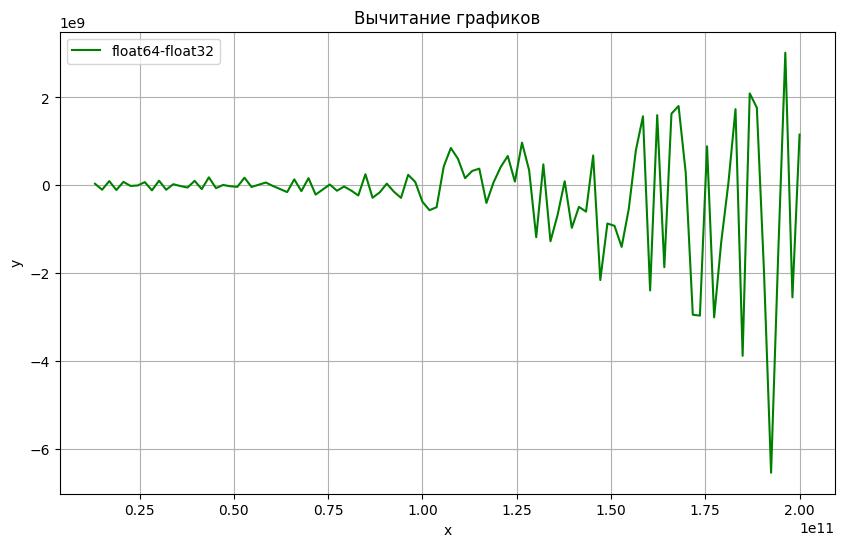

In [28]:
x = tspec

# Определяем две функции
y1 = np.array(tint0_Texact_float64).real
y2 = np.array(tint0_Texact_float32).real

# Вычитаем графики
y_diff = y1 - y2

# Создаем графики
plt.figure(figsize=(10, 6))  # Размер окна

# plt.plot(x, y1, label='sin(x)', color='blue')
# plt.plot(x, y2, label='cos(x)', color='red')
plt.plot(x, y_diff, label='float64-float32', color='green')

# Добавляем легенду, заголовки и сетку
plt.xlabel('x')
plt.ylabel('y')
plt.title('Вычитание графиков')
plt.legend()
plt.grid(True)

# Показываем график
plt.show()